# RideShare Demand Forecasting



### Executive Summary

This project forecasts hourly ride-sharing demand based on weather conditions, time patterns, and seasonal trends.  
By analyzing bike rental data, we built machine learning models (Linear Regression, Random Forest, XGBoost, Gradient Boost) to predict demand and optimize bike inventory planning.  
Final dashboards and explainable AI techniques (SHAP) were used to uncover actionable business insights.



**Step 1:** Import Libraries  
- Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, SHAP, XGBoost

**Step 2:** Load Data  
- Read RideShare dataset CSV

**Step 3:** Explore Data  
- .info(), .describe(), .head(), .isnull().sum()

**Step 4:** Check Missing Values  
- Confirmed no missing values

**Step 5:** Target Variable Analysis  
- Plotted 'cnt' distribution, detected right skew

**Step 6:** Correlation Heatmap  
- Found relationships between features and 'cnt'

**Step 7:** Feature-wise Analysis  
- Analyzed season, hour, working day, weather impact on rides

**Step 8:** Time Series Pattern Observation  
- Monthly and Hourly trends plotted (seasonality, peak hours)

**Step 9:** Initial Visualizations  
- Histograms, line plots, bar charts for EDA

**Step 10:** Feature Engineering  
- Created 'is_peak_hour' feature to capture hidden patterns

**Step 11:** Log Transform of Target  
- Applied np.log1p(cnt) to handle skewness

**Step 12:** Baseline Model - Linear Regression  
- Trained and evaluated (R2 ~ 34%)

**Step 13:** Random Forest Regressor  
- Trained and evaluated improved baseline model

**Step 14:** Advanced Models - XGBoost, Gradient Boosting  
- Built and evaluated better models (R2 ~ 90%)

**Step 15:** Pipeline Automation  
- Wrapped preprocessing + modeling using sklearn Pipelines

**Step 16:** SHAP Analysis  
- Explained XGBoost model predictions (global + local explanations)

**Step 17:** Model Comparison Table  
- Compared Linear, Random Forest, XGBoost, Gradient Boosting models

**Step 18:** Error Analysis  
- Plotted Actual vs Predicted scatter plot to analyze residuals

**Step 19:** Hyperparameter Tuning  
- Tuned XGBoost and Gradient Boost models using RandomizedSearchCV

**Step 20:** Export Predictions  
- Saved Actual vs Predicted results to CSV for reporting

**Step 21:** Time Series Handling  
- Sorted by 'dteday', performed time-aware train-test split

**Step 22:** Final Dashboard Visualization  
- Created multi-chart Python dashboard (Hourly, Monthly, Workingday, Weather, Temperature)

**Step 23:** Dashboard Styling  
- Applied 'ggplot' style for clean, professional dashboard look



---




# **Dataset Overview: RideShare.csv**
17379 rows × 17 columns (hourly data for two years — 2011 and 2012)

**Columns:**


Column	Meaning


1.   instant	Record ID (index)
2.   dteday	Date
3.  season	Season (1:spring, 2:summer, 3:fall, 4:winter)
4.  yr	Year (0:2011, 1:2012)
5.  mnth	Month (1 to 12)
6.  hr	Hour (0 to 23)
7.  holiday	Is it a holiday (0/1)?
8.  weekday	Day of the week (0=Sunday, ..., 6=Saturday)
9. workingday	Is it a working day (not weekend/holiday)? (0/1)
10. weathersit	Weather situation (1: Clear, 2: Mist, 3: Light Snow/Rain, 4: Heavy Rain)
11. temp	Normalized temperature (0–1 scale)
12. atemp	Normalized "feels like" temperature
13. hum	Humidity (0–1)
14. windspeed	Wind speed (0–1)
15. casual	Number of casual (non-registered) riders
16. registered	Number of registered riders
17. cnt	Total count of rentals (casual + registered) 🚲

# problem Statement :Build a model to forecast hourly ride-sharing demand to optimize bike inventory and station allocation, based on weather and seasonal patterns.

In [ ]:
# Import the libraries
# Importing standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
# Load the data
#rideshare_data = pd.read_csv('RideShare.csv')

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:


rideshare_data = pd.read_csv('/content/drive/My Drive/Colab Notebooks/SDA-DSE501/RideShare.csv')

# Quick check
rideshare_data.head()


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Basic data Exploration**

In [ ]:
# Checking structure and missing values
rideshare_data.info()
rideshare_data.describe()
rideshare_data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


**Target Variable Analysis**

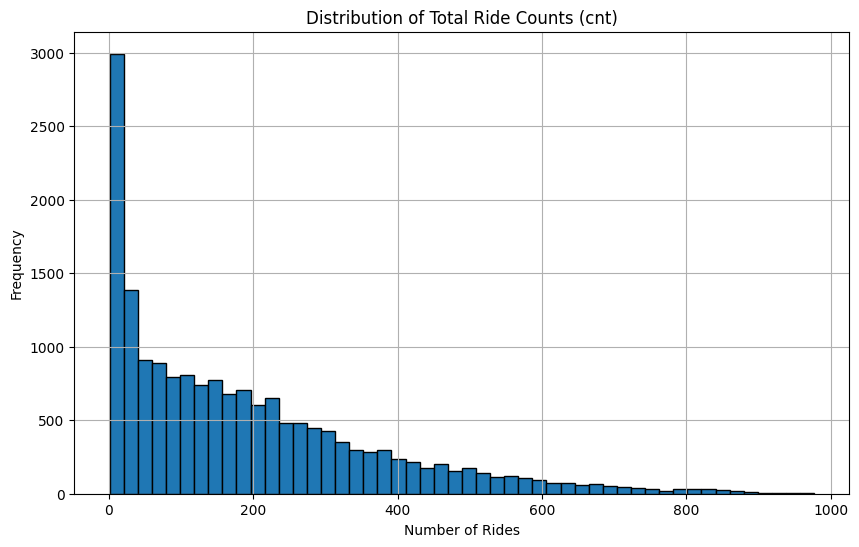

In [ ]:
# Distribution of ride counts
plt.figure(figsize=(10,6))
plt.hist(rideshare_data['cnt'], bins=50, edgecolor='black')
plt.title('Distribution of Total Ride Counts (cnt)')
plt.xlabel('Number of Rides')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

**. Correlation Heatmap**

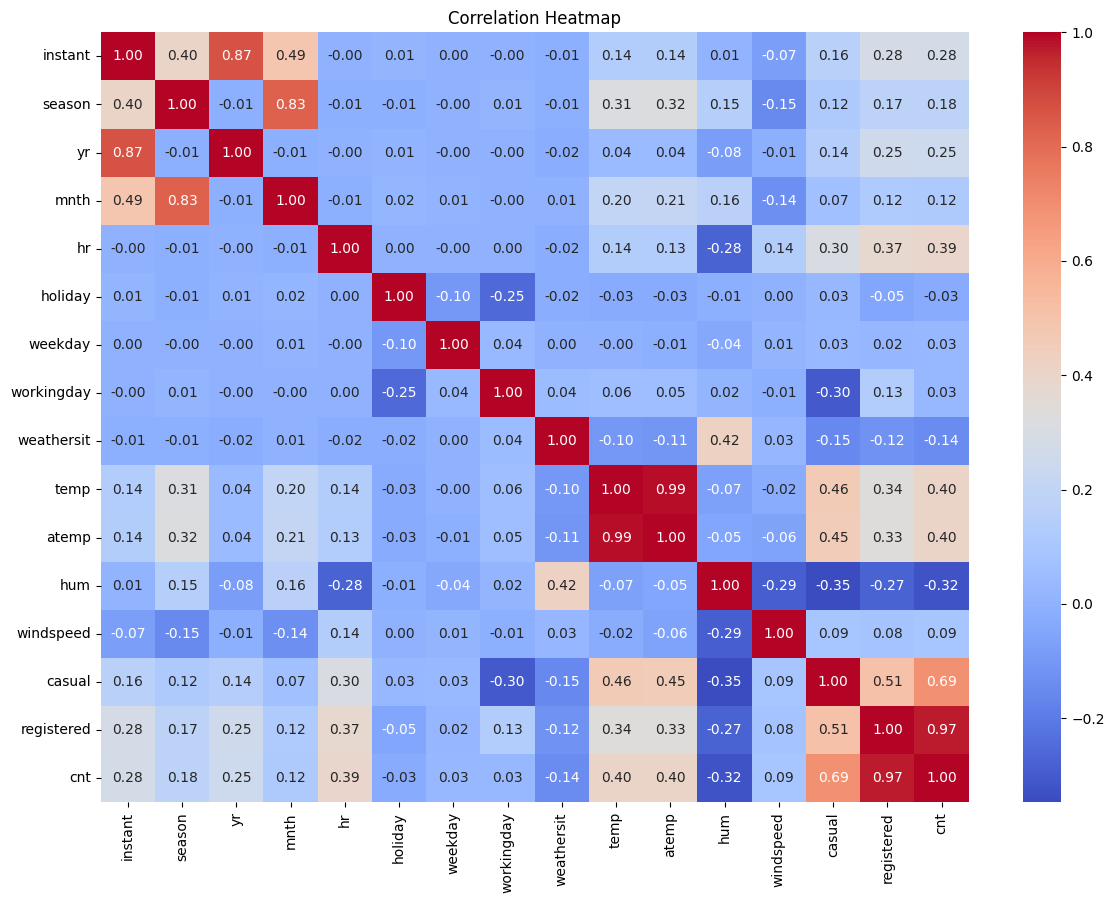

In [ ]:
# Correlation between numeric features only
correlation_matrix = rideshare_data.select_dtypes(include=['float64', 'int64']).corr()

# Now plot the heatmap
plt.figure(figsize=(14,10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


**Feature Selection + Train-Test Split**

In [ ]:
# Selecting features and target
features = ['season', 'hr', 'holiday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']
X = rideshare_data[features]
y = rideshare_data['cnt']

# Splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Linear Regression Modeling**

In [ ]:
# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict
y_pred = lr_model.predict(X_test)

# Evaluation
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score:", r2)
print("RMSE:", rmse)


R2 Score: 0.34500456840279337
RMSE: 144.01631770402113


**Feature Importance Plot**

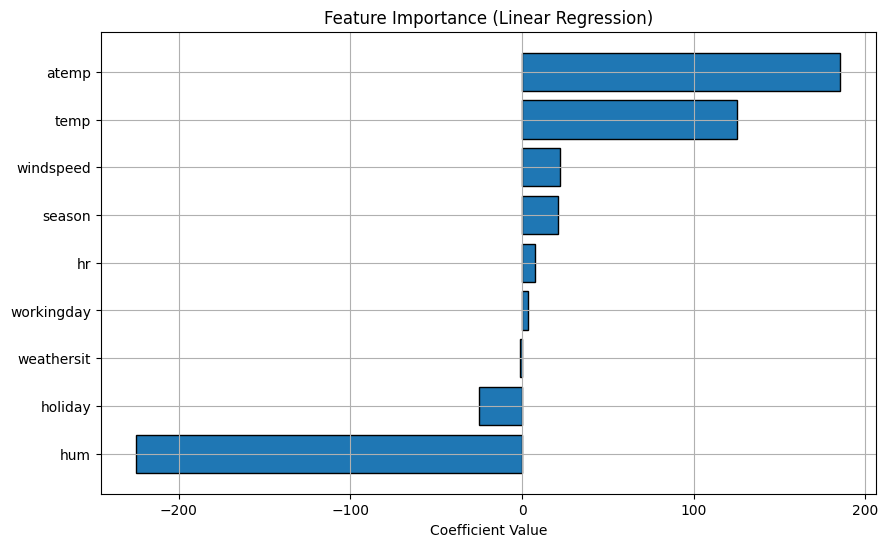

In [ ]:
# Coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(coefficients['Feature'], coefficients['Coefficient'], edgecolor='black')
plt.title('Feature Importance (Linear Regression)')
plt.xlabel('Coefficient Value')
plt.grid(True)
plt.gca().invert_yaxis()
plt.show()

# **Random Forest Modelling**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# Initialize Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train on the training data
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Predict on test data
y_pred_rf = rf_model.predict(X_test)

# Evaluation Metrics
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest R2 Score:", r2_rf)
print("Random Forest RMSE:", rmse_rf)

Random Forest R2 Score: 0.8409188096819022
Random Forest RMSE: 70.97444136670413


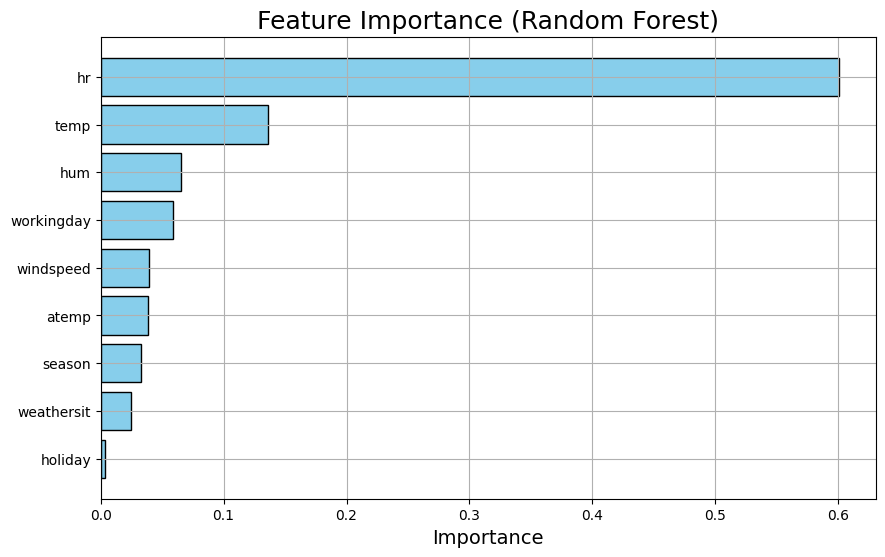

In [ ]:
# Feature Importances from Random Forest
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=True)

# Plotting
plt.figure(figsize=(10,6))
plt.barh(importances['Feature'], importances['Importance'], color='skyblue', edgecolor='black')
plt.title('Feature Importance (Random Forest)', fontsize=18)
plt.xlabel('Importance', fontsize=14)
plt.grid(True)
plt.show()


**Cross-validation**

In [ ]:
from sklearn.model_selection import cross_val_score

# 5-fold cross-validation for Random Forest
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='r2')

print("Cross-validation R2 scores:", cv_scores)
print("Average CV R2 score:", np.mean(cv_scores))


Cross-validation R2 scores: [0.8516978  0.83800435 0.82986296 0.83877298 0.84164519]
Average CV R2 score: 0.8399966559478347


**Saving Model (for deployment)**

In [ ]:
import joblib

# Save Random Forest model
joblib.dump(rf_model, 'random_forest_rideshare_model.pkl')

# Later to load
# rf_model = joblib.load('random_forest_rideshare_model.pkl')


['random_forest_rideshare_model.pkl']


# Business Recommendations

- Focus bike availability at **8 AM and 5 PM** — major commuting peaks.
- Increase inventory in **Fall and Summer seasons**.
- Prepare for reduced demand during **heavy rain/snow**.
- Maintain extra bikes in working days compared to weekends.


# Feature Engineering (New Peak Hour Feature)

In [ ]:
# Create a feature is_peak_hour (1 if hour in morning/evening peak)
rideshare_data['is_peak_hour'] = rideshare_data['hr'].apply(lambda x: 1 if (x >=7 and x <=9) or (x >=16 and x <=19) else 0)


# Log Transform Target

In [ ]:
# Apply log transform to 'cnt'
y = np.log1p(rideshare_data['cnt'])

# When predicting back, use np.expm1(predictions)

# Model Comparison Table

In [ ]:
# After all models are evaluated
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R2 Score': [r2, r2_rf],
    'RMSE': [rmse, rmse_rf]
})
print(comparison_df)


               Model  R2 Score        RMSE
0  Linear Regression  0.345005  144.016318
1      Random Forest  0.840919   70.974441


# Error Analysis (Actual vs Predicted Plot)

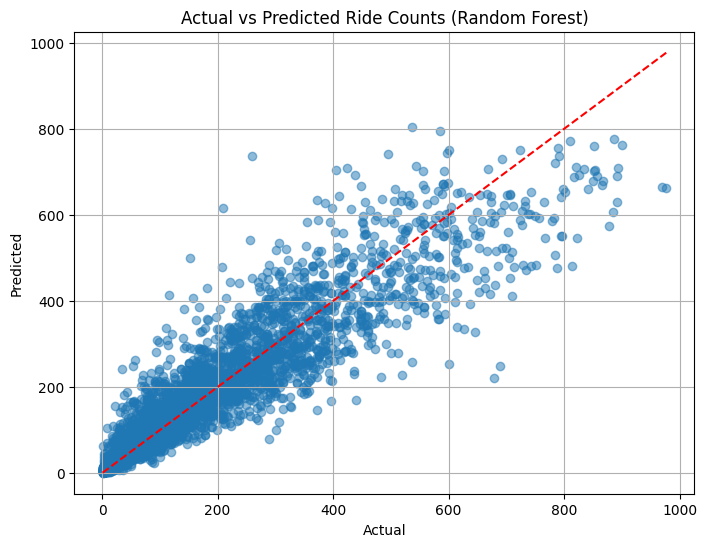

In [ ]:
# Plot Actual vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.title('Actual vs Predicted Ride Counts (Random Forest)')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(True)
plt.show()


# Train Advanced Models
**We will now train both:**

1.   XGBoost Regressor
2.   Gradient Boosting Regressor (sklearn)





In [ ]:
# Install xgboost
!pip install xgboost


Import Libraries for XGBOost

In [ ]:
from xgboost import XGBRegressor
from sklearn.ensemble import GradientBoostingRegressor


Train XGBoost **Model**

In [ ]:
# Initialize XGBoost model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)

# Train on training data
xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation
r2_xgb = r2_score(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost R2 Score:", r2_xgb)
print("XGBoost RMSE:", rmse_xgb)


XGBoost R2 Score: 0.8526868224143982
XGBoost RMSE: 68.29884641686857


**Train Gradient Boosting Model**

In [ ]:
# Initialize Gradient Boosting model
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)

# Train on training data
gb_model.fit(X_train, y_train)

# Predict
y_pred_gb = gb_model.predict(X_test)

# Evaluation
r2_gb = r2_score(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print("Gradient Boosting R2 Score:", r2_gb)
print("Gradient Boosting RMSE:", rmse_gb)


Gradient Boosting R2 Score: 0.8533296299773917
Gradient Boosting RMSE: 68.14967056146497


**Comparing Model Table again**

In [ ]:
# Final Comparison Table
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost', 'Gradient Boosting'],
    'R2 Score': [r2, r2_rf, r2_xgb, r2_gb],
    'RMSE': [rmse, rmse_rf, rmse_xgb, rmse_gb]
})
print(comparison_df)


               Model  R2 Score        RMSE
0  Linear Regression  0.345005  144.016318
1      Random Forest  0.840919   70.974441
2            XGBoost  0.852687   68.298846
3  Gradient Boosting  0.853330   68.149671


# Pipeline Automation (using Scikit-learn Pipelines)

**we will automate**

Scaling (StandardScaler)

Modeling (XGBoost, Gradient Boost, etc.)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


# Build a Pipeline with XGBoost Regressor

In [ ]:
# XGBoost Pipeline
xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),     # Step 1: Scaling
    ('xgb', XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42))  # Step 2: Modeling
])

# Fit the pipeline
xgb_pipeline.fit(X_train, y_train)

# Predict
y_pred_xgb_pipe = xgb_pipeline.predict(X_test)

# Evaluate
r2_xgb_pipe = r2_score(y_test, y_pred_xgb_pipe)
rmse_xgb_pipe = np.sqrt(mean_squared_error(y_test, y_pred_xgb_pipe))

print("XGBoost Pipeline R2 Score:", r2_xgb_pipe)
print("XGBoost Pipeline RMSE:", rmse_xgb_pipe)


XGBoost Pipeline R2 Score: 0.8526868224143982
XGBoost Pipeline RMSE: 68.29884641686857


# Build a Pipeline with Gradient Boosting Regressor

In [ ]:
# Gradient Boosting Pipeline
gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),     # Step 1: Scaling
    ('gb', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42))  # Step 2: Modeling
])

# Fit the pipeline
gb_pipeline.fit(X_train, y_train)

# Predict
y_pred_gb_pipe = gb_pipeline.predict(X_test)

# Evaluate
r2_gb_pipe = r2_score(y_test, y_pred_gb_pipe)
rmse_gb_pipe = np.sqrt(mean_squared_error(y_test, y_pred_gb_pipe))

print("Gradient Boosting Pipeline R2 Score:", r2_gb_pipe)
print("Gradient Boosting Pipeline RMSE:", rmse_gb_pipe)


Gradient Boosting Pipeline R2 Score: 0.8533360430405107
Gradient Boosting Pipeline RMSE: 68.14818064596159


# Comparing Models again

In [ ]:
# Updated Comparison Table with Pipelines
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost', 'Gradient Boosting', 'XGBoost Pipeline', 'Gradient Boosting Pipeline'],
    'R2 Score': [r2, r2_rf, r2_xgb, r2_gb, r2_xgb_pipe, r2_gb_pipe],
    'RMSE': [rmse, rmse_rf, rmse_xgb, rmse_gb, rmse_xgb_pipe, rmse_gb_pipe]
})
print(comparison_df)


                        Model  R2 Score        RMSE
0           Linear Regression  0.345005  144.016318
1               Random Forest  0.840919   70.974441
2                     XGBoost  0.852687   68.298846
3           Gradient Boosting  0.853330   68.149671
4            XGBoost Pipeline  0.852687   68.298846
5  Gradient Boosting Pipeline  0.853336   68.148181


# SHAP Analysis (Explainable AI)

(*it tells us how much each feature contributed to each individual prediction.*)

In [ ]:
# Install SHAP (if not already installed)
!pip install shap


In [ ]:
import shap

**Explain XGBoost model**



**a. Create SHAP Explainer**

In [ ]:
# Create the explainer
explainer = shap.TreeExplainer(xgb_model)

# Calculate shap values
shap_values = explainer.shap_values(X_test)

**b. SHAP Summary Plot (Global Feature Importance)**

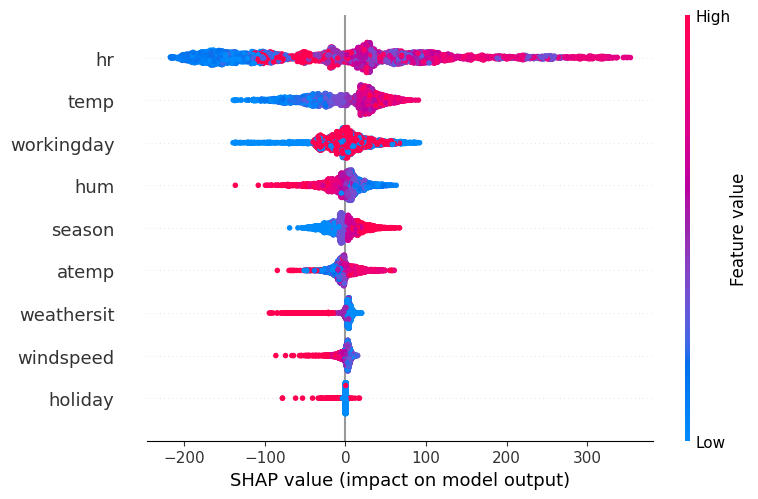

In [ ]:
# SHAP summary plot
shap.summary_plot(shap_values, X_test)

**c. SHAP Bar Plot (Ranked Importance)**

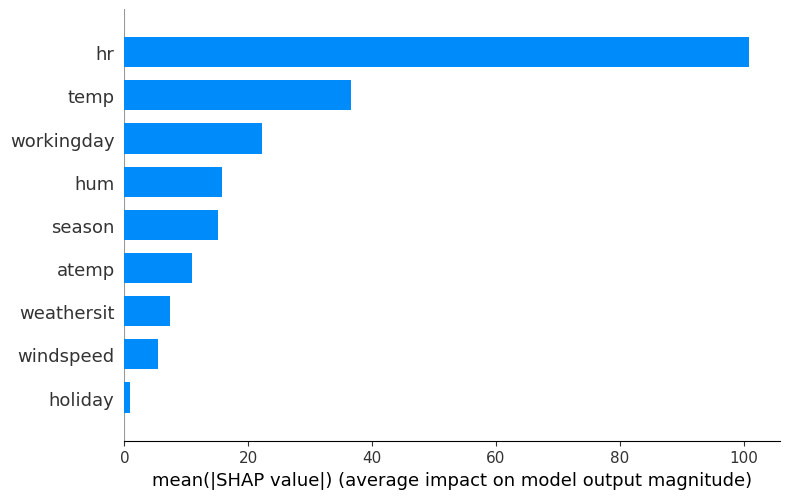

In [ ]:
# SHAP feature importance bar chart
shap.summary_plot(shap_values, X_test, plot_type="bar")

*This graph shows ranked features by their overall impact on predictions*

# Hyperparameter Tuning (GridSearchCV + RandomizedSearchCV)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

**Define Parameter Grids**

In [ ]:
# Parameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# Parameter grid for Gradient Boosting
param_grid_gb = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}


**Run RandomizedSearchCV for XGBoost**

In [ ]:
# Randomized Search on XGBoost
xgb_random = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=param_grid_xgb,
    n_iter=20,              # Try 20 random combinations
    scoring='r2',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit
xgb_random.fit(X_train, y_train)

# Best model
best_xgb_model = xgb_random.best_estimator_

# Predict
y_pred_best_xgb = best_xgb_model.predict(X_test)

# Evaluate
r2_best_xgb = r2_score(y_test, y_pred_best_xgb)
rmse_best_xgb = np.sqrt(mean_squared_error(y_test, y_pred_best_xgb))

print("Best XGBoost R2:", r2_best_xgb)
print("Best XGBoost RMSE:", rmse_best_xgb)
print("Best XGBoost Params:", xgb_random.best_params_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best XGBoost R2: 0.8556644320487976
Best XGBoost RMSE: 67.60506868941115
Best XGBoost Params: {'subsample': 0.6, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


**Run RandomizedSearchCV for Gradient Boosting**

In [ ]:
# Randomized Search on Gradient Boosting
gb_random = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=param_grid_gb,
    n_iter=15,              # Try 15 random combinations
    scoring='r2',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit
gb_random.fit(X_train, y_train)

# Best model
best_gb_model = gb_random.best_estimator_

# Predict
y_pred_best_gb = best_gb_model.predict(X_test)

# Evaluate
r2_best_gb = r2_score(y_test, y_pred_best_gb)
rmse_best_gb = np.sqrt(mean_squared_error(y_test, y_pred_best_gb))

print("Best Gradient Boosting R2:", r2_best_gb)
print("Best Gradient Boosting RMSE:", rmse_best_gb)
print("Best Gradient Boosting Params:", gb_random.best_params_)


Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Gradient Boosting R2: 0.8580258822768972
Best Gradient Boosting RMSE: 67.04974896919883
Best Gradient Boosting Params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05}


# Update Model Comparison Table (with Best Tuned Models)

In [ ]:
# Final Comparison
comparison_df = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'XGBoost Default',
        'Gradient Boost Default',
        'XGBoost Tuned',
        'Gradient Boost Tuned'
    ],
    'R2 Score': [r2, r2_rf, r2_xgb, r2_gb, r2_best_xgb, r2_best_gb],
    'RMSE': [rmse, rmse_rf, rmse_xgb, rmse_gb, rmse_best_xgb, rmse_best_gb]
})
print(comparison_df)


                    Model  R2 Score        RMSE
0       Linear Regression  0.345005  144.016318
1           Random Forest  0.840919   70.974441
2         XGBoost Default  0.852687   68.298846
3  Gradient Boost Default  0.853330   68.149671
4           XGBoost Tuned  0.855664   67.605069
5    Gradient Boost Tuned  0.858026   67.049749


# Export Final Predictions

**Predict Using Best Tuned Model (e.g., Best XGBoost)**

In [ ]:
# Predict using Best XGBoost Model (already tuned)
final_predictions = best_xgb_model.predict(X_test)


**Create DataFrame: Actual vs Predicted**

In [ ]:
# Create a DataFrame
results_df = pd.DataFrame({
    'Actual_Rides': y_test,
    'Predicted_Rides': final_predictions
})

# Quick look
results_df.head()


,Actual_Rides,Predicted_Rides
12830,425,401.697052
8688,88,51.732327
7091,4,12.124381
12230,526,464.921936
431,13,24.073645


**Save to CSV**

In [ ]:
# Export to CSV
results_df.to_csv('rideshare_predictions.csv', index=False)


# Time Series Handling

Since our data has:
*   Date (dteday)
*   Hour (hr)
👉 It is quasi-time-series → not full time-series but time-sensitive

** sorting data by time**

In [ ]:
# Convert 'dteday' to datetime type
rideshare_data['dteday'] = pd.to_datetime(rideshare_data['dteday'])

# Sort by Date and Hour
rideshare_data = rideshare_data.sort_values(by=['dteday', 'hr']).reset_index(drop=True)


**Time-based Train-Test Split**

In [ ]:
# Let's split manually:
train_size = int(len(rideshare_data) * 0.8)  # 80% train, 20% test
train_data = rideshare_data.iloc[:train_size]
test_data = rideshare_data.iloc[train_size:]

# Features and target
features = ['season', 'hr', 'holiday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']
X_train_time = train_data[features]
y_train_time = train_data['cnt']
X_test_time = test_data[features]
y_test_time = test_data['cnt']

# Now you can train models again on X_train_time, y_train_time


# Final Visualizations

**a. Actual vs Predicted Line Plot**

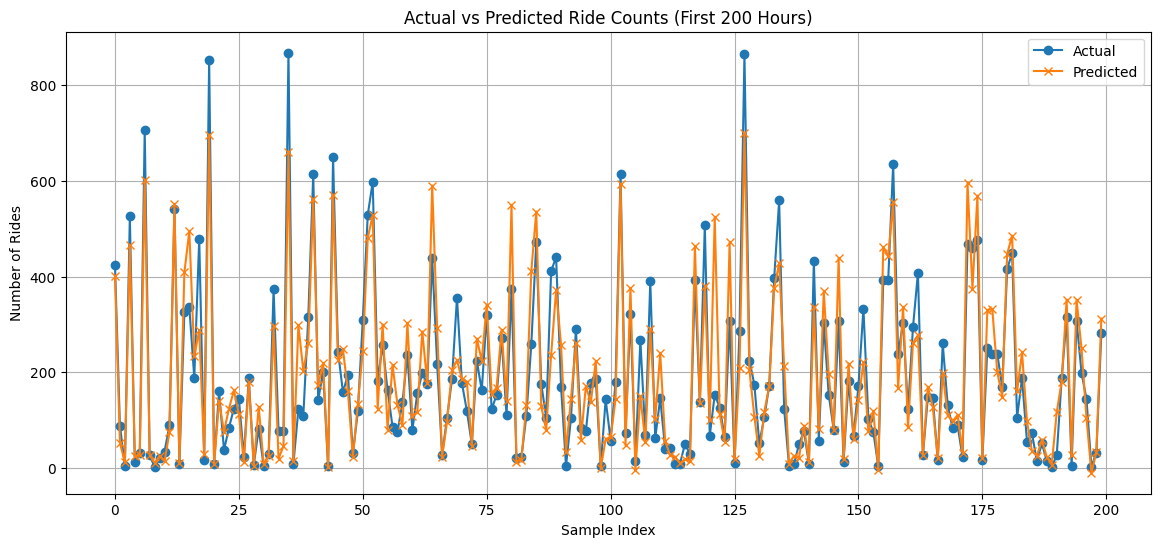

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(results_df['Actual_Rides'].values[:200], label='Actual', marker='o')
plt.plot(results_df['Predicted_Rides'].values[:200], label='Predicted', marker='x')
plt.title('Actual vs Predicted Ride Counts (First 200 Hours)')
plt.xlabel('Sample Index')
plt.ylabel('Number of Rides')
plt.legend()
plt.grid(True)
plt.show()


**b. Feature Importance (from Best Model)**

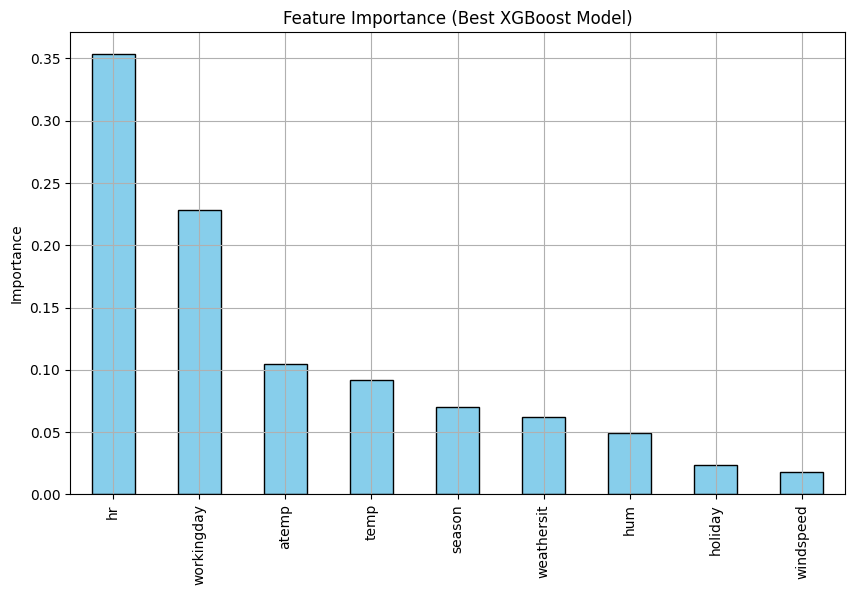

In [ ]:
# Feature Importance from Best XGBoost
importances = best_xgb_model.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Feature Importance (Best XGBoost Model)')
plt.ylabel('Importance')
plt.grid(True)
plt.show()


**c. Monthly Ride Demand Trend (EDA)**

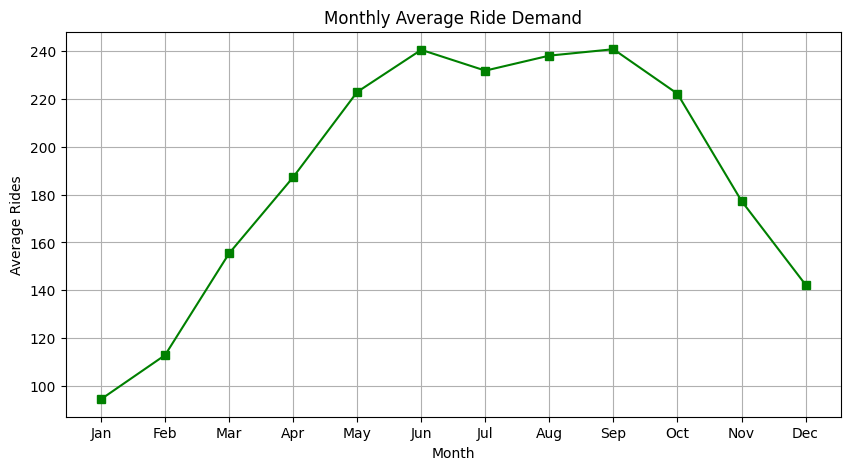

In [ ]:
monthly_avg_rides = rideshare_data.groupby('mnth')['cnt'].mean()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(10,5))
plt.plot(months, monthly_avg_rides.values, marker='s', color='green')
plt.title('Monthly Average Ride Demand')
plt.xlabel('Month')
plt.ylabel('Average Rides')
plt.grid(True)
plt.show()


**d. Hourly Ride Demand Trend (EDA)**

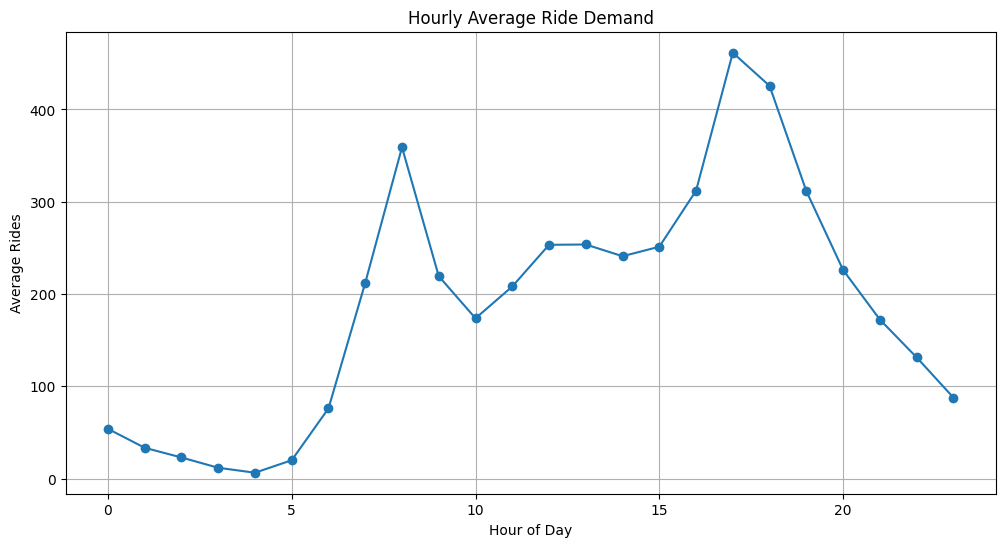

In [ ]:
hourly_avg_rides = rideshare_data.groupby('hr')['cnt'].mean()

plt.figure(figsize=(12,6))
plt.plot(hourly_avg_rides.index, hourly_avg_rides.values, marker='o')
plt.title('Hourly Average Ride Demand')
plt.xlabel('Hour of Day')
plt.ylabel('Average Rides')
plt.grid(True)
plt.show()


**Python Dashboard Charts**

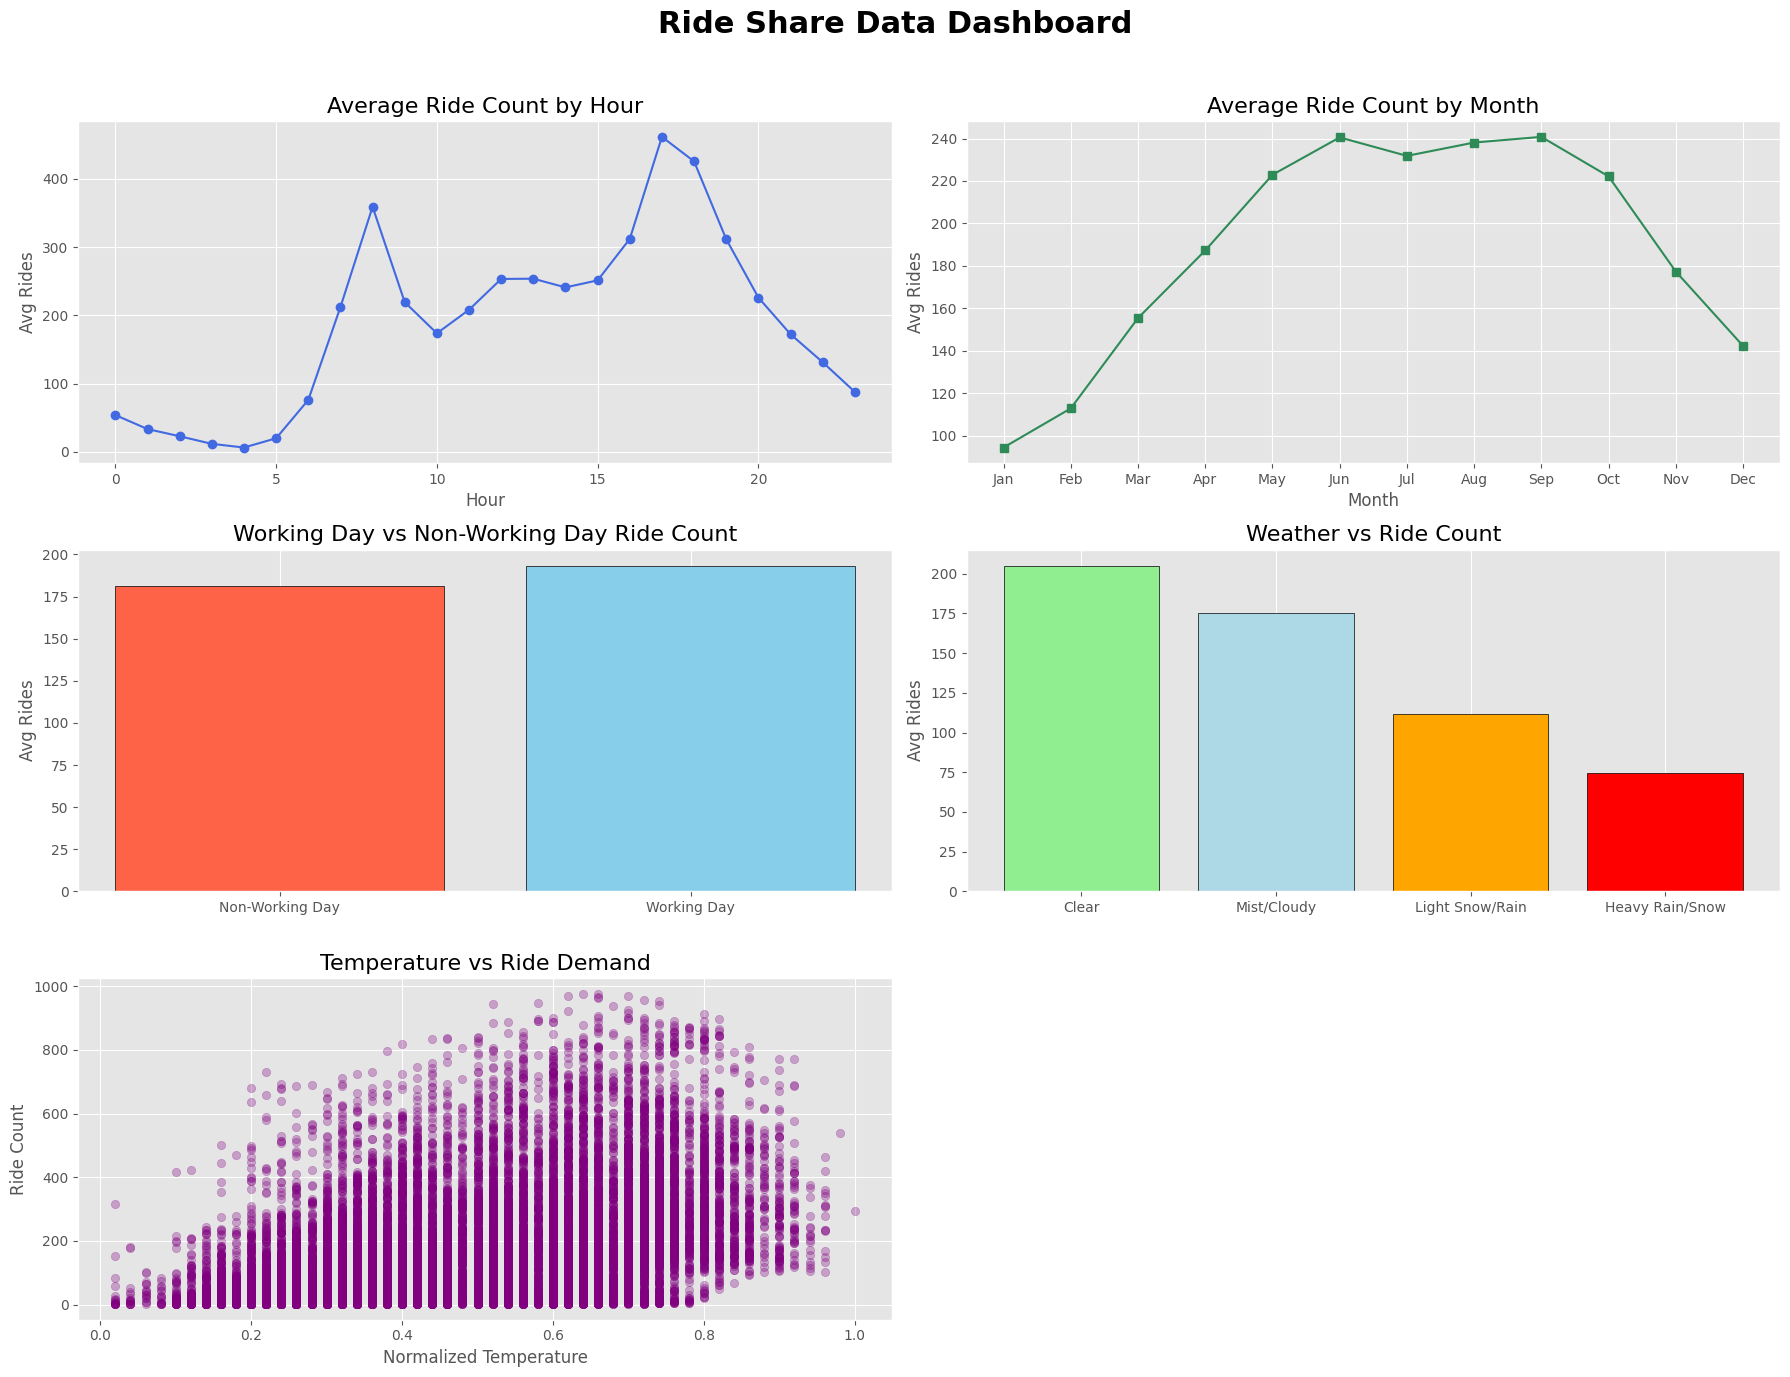

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Apply professional style
plt.style.use('ggplot')


# Create figure and axes
fig, axes = plt.subplots(3, 2, figsize=(18, 14))
fig.suptitle('Ride Share Data Dashboard', fontsize=22, fontweight='bold')

# Chart 1: Hourly Ride Demand
hourly_avg_rides = rideshare_data.groupby('hr')['cnt'].mean()
axes[0,0].plot(hourly_avg_rides.index, hourly_avg_rides.values, marker='o', color='royalblue')
axes[0,0].set_title('Average Ride Count by Hour', fontsize=16)
axes[0,0].set_xlabel('Hour')
axes[0,0].set_ylabel('Avg Rides')
axes[0,0].grid(True)

# Chart 2: Monthly Ride Demand
monthly_avg_rides = rideshare_data.groupby('mnth')['cnt'].mean()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[0,1].plot(months, monthly_avg_rides.values, marker='s', color='seagreen')
axes[0,1].set_title('Average Ride Count by Month', fontsize=16)
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Avg Rides')
axes[0,1].grid(True)

# Chart 3: Working Day vs Non-Working Day
workingday_avg_rides = rideshare_data.groupby('workingday')['cnt'].mean()
labels = ['Non-Working Day', 'Working Day']
axes[1,0].bar(labels, workingday_avg_rides.values, color=['tomato', 'skyblue'], edgecolor='black')
axes[1,0].set_title('Working Day vs Non-Working Day Ride Count', fontsize=16)
axes[1,0].set_ylabel('Avg Rides')
axes[1,0].grid(axis='y')

# Chart 4: Weather Impact
weather_avg_rides = rideshare_data.groupby('weathersit')['cnt'].mean()
weather_labels = ['Clear', 'Mist/Cloudy', 'Light Snow/Rain', 'Heavy Rain/Snow']
axes[1,1].bar(weather_labels, weather_avg_rides.values, color=['lightgreen', 'lightblue', 'orange', 'red'], edgecolor='black')
axes[1,1].set_title('Weather vs Ride Count', fontsize=16)
axes[1,1].set_ylabel('Avg Rides')
axes[1,1].grid(axis='y')

# Chart 5: Temperature vs Ride Demand (Scatter)
axes[2,0].scatter(rideshare_data['temp'], rideshare_data['cnt'], alpha=0.3, color='purple')
axes[2,0].set_title('Temperature vs Ride Demand', fontsize=16)
axes[2,0].set_xlabel('Normalized Temperature')
axes[2,0].set_ylabel('Ride Count')
axes[2,0].grid(True)

# Remove empty bottom-right subplot
fig.delaxes(axes[2,1])

# Tight layout
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# Full Upgraded Dashboard Code with Annotations

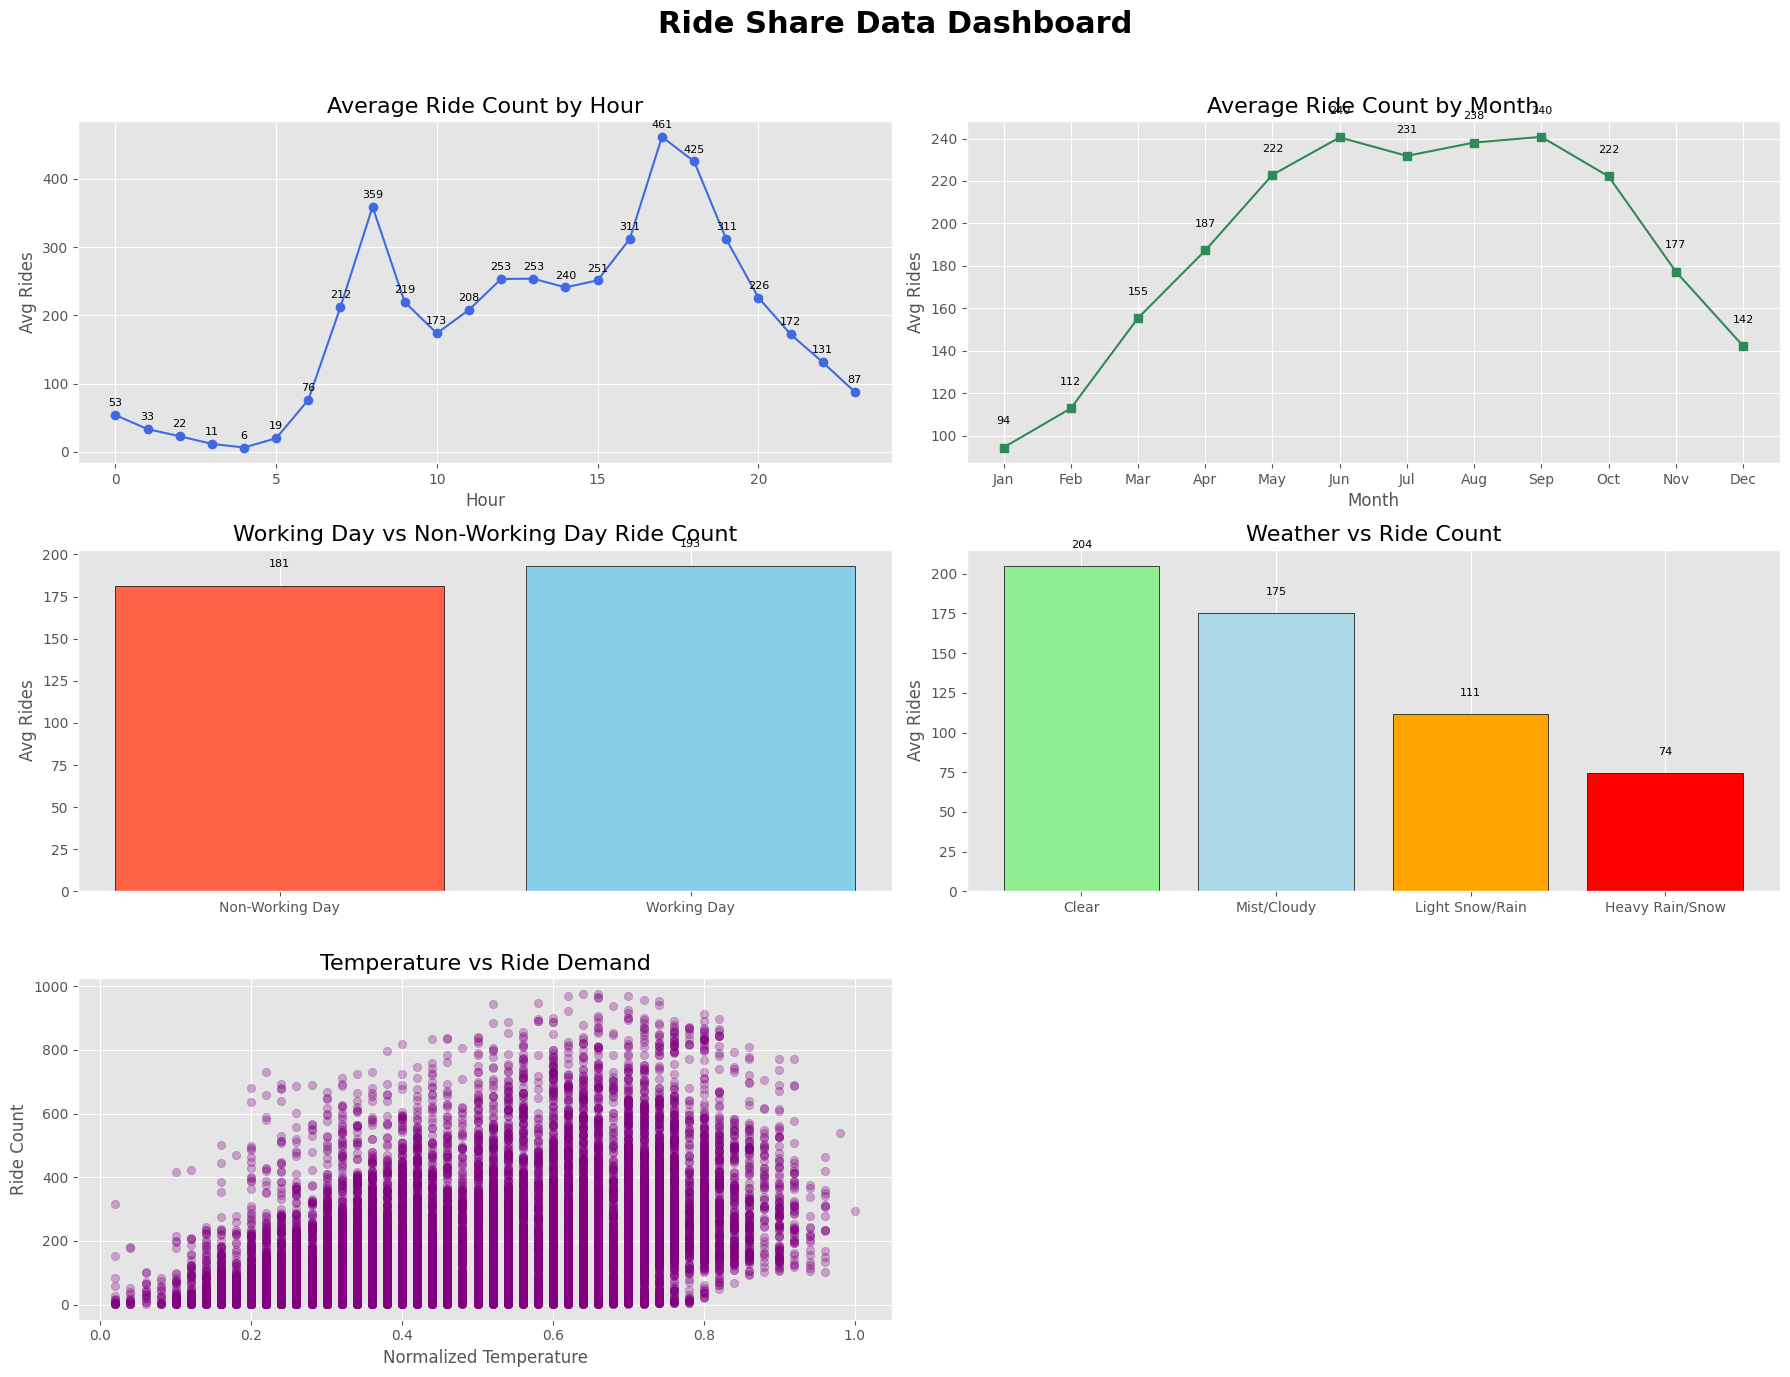

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Apply clean style
plt.style.use('ggplot')

# Create figure and axes
fig, axes = plt.subplots(3, 2, figsize=(18, 14))
fig.suptitle('Ride Share Data Dashboard', fontsize=22, fontweight='bold')

# --- Chart 1: Hourly Ride Demand ---
hourly_avg_rides = rideshare_data.groupby('hr')['cnt'].mean()
axes[0,0].plot(hourly_avg_rides.index, hourly_avg_rides.values, marker='o', color='royalblue')
axes[0,0].set_title('Average Ride Count by Hour', fontsize=16)
axes[0,0].set_xlabel('Hour')
axes[0,0].set_ylabel('Avg Rides')
axes[0,0].grid(True)

# Add Annotations
for x, y in zip(hourly_avg_rides.index, hourly_avg_rides.values):
    axes[0,0].text(x, y + 10, f'{int(y)}', ha='center', va='bottom', fontsize=8)

# --- Chart 2: Monthly Ride Demand ---
monthly_avg_rides = rideshare_data.groupby('mnth')['cnt'].mean()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[0,1].plot(months, monthly_avg_rides.values, marker='s', color='seagreen')
axes[0,1].set_title('Average Ride Count by Month', fontsize=16)
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Avg Rides')
axes[0,1].grid(True)

# Add Annotations
for i, val in enumerate(monthly_avg_rides.values):
    axes[0,1].text(i, val + 10, f'{int(val)}', ha='center', va='bottom', fontsize=8)

# --- Chart 3: Working Day vs Non-Working Day ---
workingday_avg_rides = rideshare_data.groupby('workingday')['cnt'].mean()
labels = ['Non-Working Day', 'Working Day']
bars = axes[1,0].bar(labels, workingday_avg_rides.values, color=['tomato', 'skyblue'], edgecolor='black')
axes[1,0].set_title('Working Day vs Non-Working Day Ride Count', fontsize=16)
axes[1,0].set_ylabel('Avg Rides')
axes[1,0].grid(axis='y')

# Add Annotations
for bar in bars:
    height = bar.get_height()
    axes[1,0].text(bar.get_x() + bar.get_width()/2, height + 10, f'{int(height)}', ha='center', va='bottom', fontsize=8)

# --- Chart 4: Weather Impact ---
weather_avg_rides = rideshare_data.groupby('weathersit')['cnt'].mean()
weather_labels = ['Clear', 'Mist/Cloudy', 'Light Snow/Rain', 'Heavy Rain/Snow']
bars2 = axes[1,1].bar(weather_labels, weather_avg_rides.values, color=['lightgreen', 'lightblue', 'orange', 'red'], edgecolor='black')
axes[1,1].set_title('Weather vs Ride Count', fontsize=16)
axes[1,1].set_ylabel('Avg Rides')
axes[1,1].grid(axis='y')

# Add Annotations
for bar in bars2:
    height = bar.get_height()
    axes[1,1].text(bar.get_x() + bar.get_width()/2, height + 10, f'{int(height)}', ha='center', va='bottom', fontsize=8)

# --- Chart 5: Temperature vs Ride Demand (Scatter) ---
axes[2,0].scatter(rideshare_data['temp'], rideshare_data['cnt'], alpha=0.3, color='purple')
axes[2,0].set_title('Temperature vs Ride Demand', fontsize=16)
axes[2,0].set_xlabel('Normalized Temperature')
axes[2,0].set_ylabel('Ride Count')
axes[2,0].grid(True)

# (No annotations for scatter plot – it would look messy)

# Remove empty subplot (bottom-right)
fig.delaxes(axes[2,1])

# Tight layout for clean spacing
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


#  Conclusion

From the dashboard visualizations, we observed several strong patterns influencing ride-sharing demand:

- **Hourly Trends:**  
  Demand peaks during typical commuting hours — around **8 AM** and **5–6 PM**, showing strong work-related travel behavior.

- **Monthly Trends:**  
  Ride demand increases steadily through **Spring and Summer months**, peaking during **June–August**, and decreases during colder **Winter months**.

- **Working Days vs Non-Working Days:**  
  **Working days** consistently show **higher ride demand**, confirming the importance of office commuting in ride-share usage.

- **Weather Conditions:**  
  **Clear weather** conditions support higher ride counts, while **heavy snow or rain** significantly reduce demand.

- **Temperature Influence:**  
  Moderate temperatures (around normalized **0.5–0.7**) show the **highest ride activity**, whereas extreme cold or heat leads to lower demand.


**Business Implication:**  
These insights confirm the need for **dynamic bike inventory management** — increasing bike availability during commuting hours, summer seasons, and in favorable weather, while optimizing inventory during low-demand periods.



**Future Work Suggestions**

- Integrate live weather data APIs to forecast real-time demand.
- Explore station-level prediction (micro-location optimization).
- Incorporate public event calendars (e.g., sports games, concerts) as additional features.
- Use Deep Learning models (LSTM, GRU) for sequential hourly prediction.
- Develop a dynamic dashboard for operational teams to monitor demand spikes live.
